# **Data Visualization and Exploration**

In [1]:
# Standard Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Import data as pandas dataframe

df = pd.read_json(r'C:\Users\Nandita\Downloads\End-to-End-Deep-Learning-for-Autonomous-Driving\notebooks\dataset.json')

In [5]:
df.head()

,image_front_right,image_front,image_front_left,seg_front,boxes,box_labels,velocity_x,velocity_y,velocity_z,speed_kmh,throttle,steer,brake
0,data/hf_data\images\0_front_right.png,data/hf_data\images\0_front.png,data/hf_data\images\0_left.png,data/hf_data\images\0_seg_front.png,"[[339.4227294921875, 294.1184387207031, 349.53...","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",0.639446,0.002091,-2.934452,10.811935,0.850000,0.000351,0.0
1,data/hf_data\images\1_front_right.png,data/hf_data\images\1_front.png,data/hf_data\images\1_left.png,data/hf_data\images\1_seg_front.png,"[[338.8574523925781, 302.9876403808594, 348.99...","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",1.683788,0.008693,0.494329,6.317543,0.850000,0.000880,0.0
2,data/hf_data\images\2_front_right.png,data/hf_data\images\2_front.png,data/hf_data\images\2_left.png,data/hf_data\images\2_seg_front.png,"[[337.7853088378906, 299.66204833984375, 347.9...","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",2.653988,0.008784,0.026236,9.554874,0.850000,0.000000,0.0
3,data/hf_data\images\3_front_right.png,data/hf_data\images\3_front.png,data/hf_data\images\3_left.png,data/hf_data\images\3_seg_front.png,"[[336.12811279296875, 301.38812255859375, 346....","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",3.277794,0.010660,-0.037987,11.800915,0.252776,0.000000,0.0
4,data/hf_data\images\4_front_right.png,data/hf_data\images\4_front.png,data/hf_data\images\4_left.png,data/hf_data\images\4_seg_front.png,"[[333.96063232421875, 302.7830505371094, 344.2...","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",3.742375,0.012229,-0.003158,13.472628,0.850000,0.000000,0.0


In [7]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (10000, 13)

Columns: ['image_front_right', 'image_front', 'image_front_left', 'seg_front', 'boxes', 'box_labels', 'velocity_x', 'velocity_y', 'velocity_z', 'speed_kmh', 'throttle', 'steer', 'brake']


# Dataset Summary

Sensors: front, front-left, front-right

Annotations: 2D bounding boxes and class labels (vehicles, pedestrians) w.r.t front 

- image_front, image_front_left, image_front_right, image_rear (images): RGB views
- seg_front (image): Semantic segmentation (front view)
- boxes (list[list[float32]]): 2D bounding boxes in [xmin, ymin, xmax, ymax] format
- box_labels (list[string]): Class labels for bounding boxes
- velocity_{x,y,z} (float): Ego velocity (m/s)
- speed_kmh (float): Ego speed (km/h)
- throttle, steer, brake (float): Control inputs


In [10]:
# Missing values

print("\nMissing values:")
print(df.isna().sum())


Missing values:
image_front_right    0
image_front          0
image_front_left     0
seg_front            3
boxes                0
box_labels           0
velocity_x           0
velocity_y           0
velocity_z           0
speed_kmh            0
throttle             0
steer                0
brake                0
dtype: int64


In [12]:
# Data types

print("\nDtypes:")
print(df.dtypes)


Dtypes:
image_front_right     object
image_front           object
image_front_left      object
seg_front             object
boxes                 object
box_labels            object
velocity_x           float64
velocity_y           float64
velocity_z           float64
speed_kmh            float64
throttle             float64
steer                float64
brake                float64
dtype: object


In [14]:
# Quick stats

df[[
    "velocity_x", "velocity_y", "velocity_z",
    "speed_kmh", "throttle", "steer", "brake"
]].describe()

,velocity_x,velocity_y,velocity_z,speed_kmh,throttle,steer,brake
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.134902,-0.085620,-0.001028,16.256899,0.097458,-0.047180,0.397127
std,4.361789,3.955193,0.067604,13.615581,0.189699,0.146663,0.480417
min,-8.292768,-8.324524,-2.938835,0.000000,0.000000,-0.688446,0.000000
25%,-0.093744,-0.068699,-0.007256,0.000000,0.000000,-0.128654,0.000000
50%,0.000000,0.000000,0.000000,20.562533,0.034576,-0.018823,0.000000
75%,0.264914,0.054731,0.009280,29.715005,0.111164,0.031851,1.000000
max,8.296423,8.289923,0.548462,29.970631,0.850000,0.757145,1.000000


# Braking Behavior Analysis

In [17]:
# How often is brake applied?
brake_counts = (df["brake"] > 0).value_counts()
print("\nBrake applied vs not applied:")
print(brake_counts)

# % of braking frames
brake_ratio = (df["brake"] > 0).mean() * 100
print(f"\n% Frames with braking: {brake_ratio:.2f}%")


Brake applied vs not applied:
brake
False    5062
True     4938
Name: count, dtype: int64

% Frames with braking: 49.38%


# Speed vs Brake Relationship

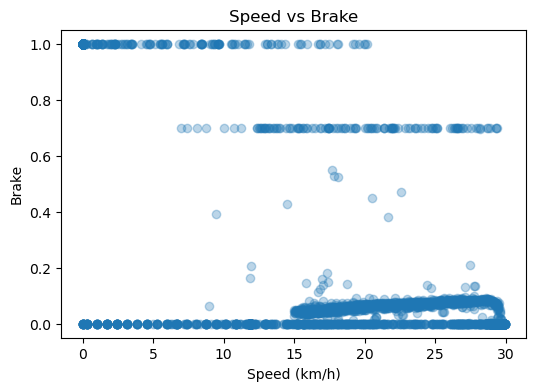

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(df["speed_kmh"], df["brake"], alpha=0.3)
plt.xlabel("Speed (km/h)")
plt.ylabel("Brake")
plt.title("Speed vs Brake")
plt.show()

# Throttle vs Brake Conflict Check

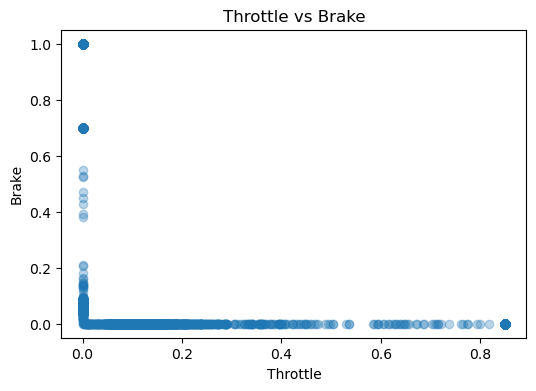

Samples where throttle > 0 AND brake > 0:
Empty DataFrame
Columns: [image_front_right, image_front, image_front_left, seg_front, boxes, box_labels, velocity_x, velocity_y, velocity_z, speed_kmh, throttle, steer, brake]
Index: []


In [23]:
plt.figure(figsize=(6,4))
plt.scatter(df["throttle"], df["brake"], alpha=0.3)
plt.xlabel("Throttle")
plt.ylabel("Brake")
plt.title("Throttle vs Brake")
plt.show()

print("Samples where throttle > 0 AND brake > 0:")
print(df[(df["throttle"] > 0.2) & (df["brake"] > 0)].head())


# Steering Distribution

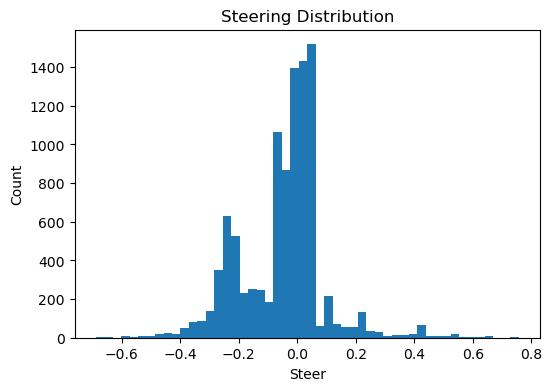

In [26]:
plt.figure(figsize=(6,4))
plt.hist(df["steer"], bins=50)
plt.xlabel("Steer")
plt.ylabel("Count")
plt.title("Steering Distribution")
plt.show()

# Object Density vs Braking

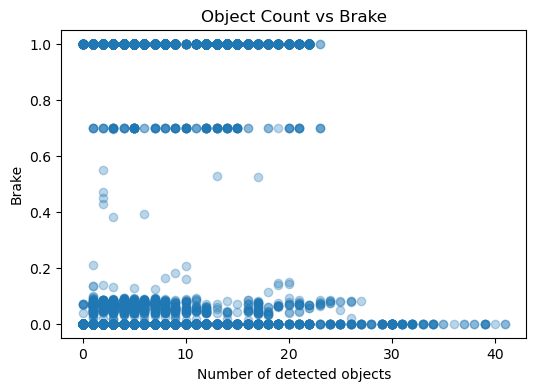


Avg brake by object count:
num_boxes
0    0.094941
1    0.142376
2    0.298387
3    0.284295
4    0.352855
5    0.423307
6    0.465053
7    0.277540
8    0.492468
9    0.349147
Name: brake, dtype: float64


In [29]:
# Count boxes per frame
df["num_boxes"] = df["boxes"].apply(lambda x: len(x) if isinstance(x, list) else 0)

plt.figure(figsize=(6,4))
plt.scatter(df["num_boxes"], df["brake"], alpha=0.3)
plt.xlabel("Number of detected objects")
plt.ylabel("Brake")
plt.title("Object Count vs Brake")
plt.show()

print("\nAvg brake by object count:")
print(df.groupby("num_boxes")["brake"].mean().head(10))


# Class Distribution of Detected Objects

In [32]:
from collections import Counter

all_labels = []
for labels in df["box_labels"]:
    if isinstance(labels, list):
        all_labels.extend(labels)

label_counts = Counter(all_labels)
label_df = pd.DataFrame(label_counts.items(), columns=["class", "count"]).sort_values("count", ascending=False)
label_df.head(10)


,class,count
0,vehicle,71143
1,pedestrian,4041
